Question 1: Implement the following Morphological Operations using OpenCV in Python:
- LBP (Local Binary Patterns)
- Erosion
- Expansion (Dilation)

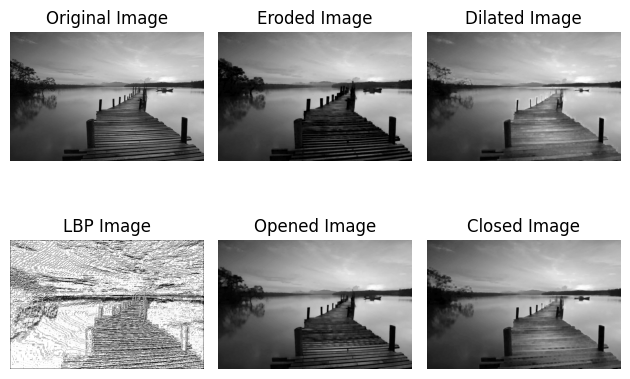

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("./gray_original.png", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(img, kernel, iterations=1)

dilation = cv2.morphologyEx(img, cv2.MORPH_DILATE, kernel)

opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)


def lbp(image):
    lbp_image = np.zeros_like(image)
    for i in range(1, image.shape[0] - 1):
        for j in range(1, image.shape[1] - 1):
            center = image[i, j]
            binary_string = ""
            binary_string += "1" if image[i - 1, j - 1] >= center else "0"
            binary_string += "1" if image[i - 1, j] >= center else "0"
            binary_string += "1" if image[i - 1, j + 1] >= center else "0"
            binary_string += "1" if image[i, j + 1] >= center else "0"
            binary_string += "1" if image[i + 1, j + 1] >= center else "0"
            binary_string += "1" if image[i + 1, j] >= center else "0"
            binary_string += "1" if image[i + 1, j - 1] >= center else "0"
            binary_string += "1" if image[i, j - 1] >= center else "0"
            lbp_value = int(binary_string, 2)
            lbp_image[i, j] = lbp_value
    return lbp_image


lbp_image = lbp(img)

plt.subplot(2, 3, 1)
_ = plt.imshow(img, cmap="gray")
_ = plt.title("Original Image")
_ = plt.axis("off")

plt.subplot(2, 3, 2)
_ = plt.imshow(erosion, cmap="gray")
_ = plt.title("Eroded Image")
_ = plt.axis("off")

plt.subplot(2, 3, 3)
_ = plt.imshow(dilation, cmap="gray")
_ = plt.title("Dilated Image")
_ = plt.axis("off")

plt.subplot(2, 3, 4)
_ = plt.imshow(lbp_image, cmap="gray")
_ = plt.title("LBP Image")
_ = plt.axis("off")

plt.subplot(2, 3, 5)
_ = plt.imshow(opening, cmap="gray")
_ = plt.title("Opened Image")
_ = plt.axis("off")

plt.subplot(2, 3, 6)
_ = plt.imshow(closing, cmap="gray")
_ = plt.title("Closed Image")
_ = plt.axis("off")

plt.tight_layout()
plt.show()